# v1_corrigido — pipeline limpo, baseline, walk-forward e Recall@K

**Projeto:** Risco de abandono escolar em Roraima (PIBIC/UERR + Mineração de Dados)
**Base:** `dados/processado/base_longitudinal_rr_2019_2025.parquet` (6.054 × 59)

Este notebook substitui o `v1.ipynb`. Ele aplica as correções pedidas pelo
orientador na revisão do pacote `v1` + `v1_old`.

## O que foi corrigido em relação ao `v1.ipynb`

| # | Problema no `v1` | Correção aqui |
|---|---|---|
| 1 | Não filtrava escolas públicas | `REDE_PUBLICA == 1` (seção 2) |
| 2 | Imputação não pegava `Float64`/`Int8` e caía em `fillna(0)` | Conversão explícita para `float64` + `SimpleImputer(median)` dentro do `Pipeline` (seção 4) |
| 3 | Imputação antes do split (leakage) | Imputer ajustado **só no treino**, dentro do `Pipeline` (seção 4) |
| 4 | Categóricas descartadas por `select_dtypes(include=[np.number])` | `ColumnTransformer` + `OneHotEncoder` (seção 4) |
| 5 | Modelo AF via features do EM (falha do `v1_old`) | Features por etapa, decisão **D15** (seção 3) |
| 6 | Sem baseline | Persistência, média e mediana do treino (seção 5) |
| 7 | Teste em um único ano | Walk-forward ano a ano (seção 6) |
| 8 | Sem classificação | Precisão, recall, F1, ROC-AUC, PR-AUC (seção 9) |
| 9 | Sem métrica operacional | Recall@K e Precision@K (seção 10) |
| 10 | Importância por impureza (instável com TDI colinear) | Permutation importance (seção 8) |
| 11 | MAE reportado como `%` | Reportado em **p.p.** (pontos percentuais) |
| 12 | "Melhor modelo" escolhido pelo R² do próprio teste | Escolha pelo walk-forward; 2024→2025 fica como teste final |

## O que NÃO foi feito aqui, e por quê

- **Enriquecimento da base** (escola indígena, terra indígena, assentamento,
  HAD, IED 2019–2020, Pé-de-Meia por escola). Depende dos microdados do Censo,
  que não estão nesta pasta — só a base longitudinal. É a **Fase 3**.
- **SHAP.** Exige o pacote `shap`, fora do `requirements.txt` atual. A
  permutation importance (seção 8) já responde a parte da pergunta.
- **Flag de Pé-de-Meia como feature.** Ela vale 1 apenas em 2024–2025, que são
  justamente os anos de teste. Num split temporal o modelo nunca a vê variar no
  treino, então ela não é estimável. Entra como recorte de análise, não como
  feature. Ver seção 11.

In [1]:
# ============================================================
# 1. CONFIGURAÇÃO
# ============================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestClassifier, HistGradientBoostingClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
)
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# ------------------------------------------------------------
# Parâmetros do experimento
# ------------------------------------------------------------
APENAS_PUBLICAS = True      # Correção 1. Universo do estudo.
EXCLUIR_ANO_2019 = True     # 2019 não tem _LAG1 nem _DELTA1 (não existe 2018).
INCLUIR_CONTEXTO_FUN_NO_EM = False   # Q8 em aberto. D15 = cada modelo só vê sua etapa.

ANO_TESTE_FINAL = 2024      # features de 2024 → alvo de 2025. Último par completo.
N_BOOTSTRAP = 1000          # reamostragens para os intervalos de confiança
PERCENTIL_RISCO = 80        # Q10 em aberto. Limiar calculado SÓ no treino.

# ------------------------------------------------------------
# Caminho da base
# ------------------------------------------------------------
_CANDIDATOS = [
    Path.cwd().parent / "dados" / "processado",
    Path.cwd() / "dados" / "processado",
    Path.cwd(),
]
BASE_LONG = None
for _d in _CANDIDATOS:
    _p = _d / "base_longitudinal_rr_2019_2025.parquet"
    if _p.exists():
        BASE_LONG = _p
        break
if BASE_LONG is None:
    raise FileNotFoundError(
        "base_longitudinal_rr_2019_2025.parquet não encontrada. "
        f"Procurei em: {[str(d) for d in _CANDIDATOS]}"
    )

print(f"Base: {BASE_LONG}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

Base: c:\Users\gusta\Meu Drive\Faculdade\Projeto da Gabi\dados\processado\base_longitudinal_rr_2019_2025.parquet
RANDOM_STATE = 1


In [2]:
# ============================================================
# 2. CARREGAMENTO E UNIVERSO
# ------------------------------------------------------------
# Correção 1: apenas escolas públicas.
# ============================================================
df = pd.read_parquet(BASE_LONG)
print(f"Base completa                 : {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Escolas únicas                : {df['CO_ENTIDADE'].nunique():,}")

if APENAS_PUBLICAS:
    df = df[df["REDE_PUBLICA"] == 1].copy()
    print(f"Após REDE_PUBLICA == 1        : {df.shape[0]:,} linhas")

if EXCLUIR_ANO_2019:
    df = df[df["ANO"] > 2019].copy()
    print(f"Após excluir ANO = 2019       : {df.shape[0]:,} linhas")

# A linha de 2025 não tem alvo (o abandono de 2026 ainda não existe).
# Fica reservada para inferência futura, não entra em treino nem teste.
df_inferencia = df[df["ANO_ALVO"].isna()].copy()
df = df[df["ANO_ALVO"].notna()].copy()
print(f"Modelável (ANO_ALVO não nulo) : {df.shape[0]:,} linhas")
print(f"Reservado p/ inferência (2025): {df_inferencia.shape[0]:,} linhas")

Base completa                 : 6,054 linhas × 59 colunas
Escolas únicas                : 934
Após REDE_PUBLICA == 1        : 5,760 linhas
Após excluir ANO = 2019       : 4,962 linhas
Modelável (ANO_ALVO não nulo) : 4,063 linhas
Reservado p/ inferência (2025): 899 linhas


In [3]:
# ============================================================
# 3. DEFINIÇÃO DAS FEATURES POR ETAPA
# ------------------------------------------------------------
# Correção 5 (D15): cada modelo só vê as features da sua etapa.
# O v1_old entregava todas as numéricas ao modelo AF, inclusive as do EM —
# por isso TDI_MED_TOTAL aparecia no top 5 do modelo de anos finais.
#
# Correção 4: as categóricas são declaradas aqui e tratadas na seção 4,
# em vez de serem silenciosamente descartadas por select_dtypes.
# ============================================================
ALVOS = ["ABANDONO_FUN_T1", "ABANDONO_FUN_AF_T1", "ABANDONO_MED_T1"]

# Nunca entram como feature: IDs, nomes, anos.
DROP_SEMPRE = [
    "CO_ENTIDADE", "NO_ENTIDADE", "NO_MUNICIPIO",
    "ANO", "ANO_ALVO", "REDE_PUBLICA",
]

CAT_COLS = ["LOCALIZACAO", "DEPENDENCIA", "CO_MUNICIPIO"]
FLAG_COLS = ["DISP_ATU", "DISP_TDI", "DISP_IED", "DISP_REND"]

NUM_AF = [
    # Anos finais — núcleo
    "ATU_FUN_AF", "ATU_FUN_TOTAL",
    "TDI_FUN_AF", "TDI_FUN_TOTAL",
    "APROVACAO_FUN_AF", "REPROVACAO_FUN_AF", "ABANDONO_FUN_AF",
    "APROVACAO_FUN", "REPROVACAO_FUN", "ABANDONO_FUN",
    # Defasagens e variações
    "ABANDONO_FUN_AF_LAG1", "ABANDONO_FUN_LAG1",
    "ABANDONO_FUN_AF_DELTA1", "TDI_FUN_AF_DELTA1", "ATU_FUN_AF_DELTA1",
    # Esforço docente do fundamental
    "IED_FUN_N1", "IED_FUN_N2", "IED_FUN_N3",
    "IED_FUN_N4", "IED_FUN_N5", "IED_FUN_N6", "IED_FUN_ALTO",
    # Anos iniciais como contexto da mesma escola
    "ATU_FUN_AI", "TDI_FUN_AI",
    "APROVACAO_FUN_AI", "REPROVACAO_FUN_AI", "ABANDONO_FUN_AI",
]

NUM_EM = [
    "ATU_MED_TOTAL", "TDI_MED_TOTAL",
    "APROVACAO_MED", "REPROVACAO_MED", "ABANDONO_MED",
    "ABANDONO_MED_LAG1",
    "ABANDONO_MED_DELTA1", "TDI_MED_TOTAL_DELTA1", "ATU_MED_TOTAL_DELTA1",
    "IED_MED_N1", "IED_MED_N2", "IED_MED_N3",
    "IED_MED_N4", "IED_MED_N5", "IED_MED_N6", "IED_MED_ALTO",
]

if INCLUIR_CONTEXTO_FUN_NO_EM:
    NUM_EM = NUM_EM + [
        "TDI_FUN_TOTAL", "ATU_FUN_TOTAL",
        "APROVACAO_FUN", "REPROVACAO_FUN", "ABANDONO_FUN",
    ]

ETAPAS = {
    "Anos finais": {
        "alvo": "ABANDONO_FUN_AF_T1",
        "persistencia": "ABANDONO_FUN_AF",   # abandono(t) da mesma etapa
        "num": NUM_AF,
    },
    "Ensino medio": {
        "alvo": "ABANDONO_MED_T1",
        "persistencia": "ABANDONO_MED",
        "num": NUM_EM,
    },
}


def preparar(df_base, cfg):
    """Monta X, y e os metadados de uma etapa.

    Correção 3 (parte): nenhuma imputação acontece aqui. X sai com os nulos
    preservados; quem imputa é o Pipeline, já dentro de cada fold.
    """
    alvo = cfg["alvo"]
    d = df_base[df_base[alvo].notna()].copy()

    num_cols = [c for c in cfg["num"] + FLAG_COLS if c in d.columns]
    cat_cols = [c for c in CAT_COLS if c in d.columns]

    # Correção 2: a base usa Float64 / Int8 / Int16 (tipos nullable do pandas).
    # select_dtypes(['float64','int64']) não pega nenhuma delas. Aqui a conversão
    # é explícita, e pd.NA vira np.nan para o SimpleImputer tratar.
    X = d[num_cols + cat_cols].copy()
    X[num_cols] = X[num_cols].astype("float64")
    for c in cat_cols:
        X[c] = X[c].astype("object")

    y = d[alvo].astype("float64")
    meta = d[["CO_ENTIDADE", "ANO", "ANO_ALVO", cfg["persistencia"]]].copy()
    meta[cfg["persistencia"]] = meta[cfg["persistencia"]].astype("float64")

    # Checagem de leakage: nenhum alvo pode ter sobrado dentro de X.
    vazou = [c for c in X.columns if c in ALVOS]
    assert not vazou, f"LEAKAGE: alvo dentro de X → {vazou}"

    return X, y, meta, num_cols, cat_cols


DADOS = {}
for nome, cfg in ETAPAS.items():
    X, y, meta, num_cols, cat_cols = preparar(df, cfg)
    DADOS[nome] = dict(X=X, y=y, meta=meta, num=num_cols, cat=cat_cols, cfg=cfg)
    print(f"\n=== {nome} ===")
    print(f"  Linhas          : {len(X):,}   Escolas: {meta['CO_ENTIDADE'].nunique():,}")
    print(f"  Features num.   : {len(num_cols)}")
    print(f"  Features categ. : {len(cat_cols)} → {cat_cols}")
    print(f"  Alvo            : {cfg['alvo']}")
    print(f"  Alvos irmãos em X? {'SIM — ERRO' if any(c in ALVOS for c in X.columns) else 'não'}")
    print(f"  Linhas por ANO  : {meta['ANO'].value_counts().sort_index().to_dict()}")
    print(f"  Zeros no alvo   : {(y == 0).mean():.1%}")


=== Anos finais ===
  Linhas          : 1,182   Escolas: 254
  Features num.   : 31
  Features categ. : 3 → ['LOCALIZACAO', 'DEPENDENCIA', 'CO_MUNICIPIO']
  Alvo            : ABANDONO_FUN_AF_T1
  Alvos irmãos em X? não
  Linhas por ANO  : {np.int16(2020): 233, np.int16(2021): 235, np.int16(2022): 232, np.int16(2023): 239, np.int16(2024): 243}
  Zeros no alvo   : 35.3%

=== Ensino medio ===
  Linhas          : 823   Escolas: 174
  Features num.   : 20
  Features categ. : 3 → ['LOCALIZACAO', 'DEPENDENCIA', 'CO_MUNICIPIO']
  Alvo            : ABANDONO_MED_T1
  Alvos irmãos em X? não
  Linhas por ANO  : {np.int16(2020): 158, np.int16(2021): 160, np.int16(2022): 166, np.int16(2023): 168, np.int16(2024): 171}
  Zeros no alvo   : 20.9%


In [4]:
# ============================================================
# 4. PRÉ-PROCESSAMENTO E MODELOS
# ------------------------------------------------------------
# Correções 2, 3 e 4, todas resolvidas pela mesma estrutura:
# o pré-processamento vira um passo do Pipeline, então é ajustado
# exclusivamente no treino de cada fold e só depois aplicado ao teste.
# ============================================================
def construir_preprocessador(num_cols, cat_cols):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),   # mediana: há outliers
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer(
        [("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)],
        remainder="drop",
    )


def modelos_regressao():
    return {
        "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
        "RandomForest": RandomForestRegressor(
            n_estimators=300, max_depth=10, min_samples_leaf=3,
            random_state=RANDOM_STATE, n_jobs=-1,
        ),
        "GradientBoosting": GradientBoostingRegressor(
            n_estimators=100, random_state=RANDOM_STATE,
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, max_depth=6,
            random_state=RANDOM_STATE,
        ),
    }


def montar_pipeline(modelo, num_cols, cat_cols):
    return Pipeline([
        ("pre", construir_preprocessador(num_cols, cat_cols)),
        ("model", modelo),
    ])


print("Pré-processamento: mediana + scaler (numéricas) | 'Missing' + one-hot (categóricas)")
print(f"Modelos de regressão: {list(modelos_regressao())}")

Pré-processamento: mediana + scaler (numéricas) | 'Missing' + one-hot (categóricas)
Modelos de regressão: ['Ridge', 'RandomForest', 'GradientBoosting', 'HistGradientBoosting']


In [5]:
# ============================================================
# 5. MÉTRICAS E BASELINES
# ------------------------------------------------------------
# Correção 6. O 03_METODOLOGIA afirma que o baseline de persistência tem
# "R² = 0 por definição". Isso não é verdade: R² = 0 é a previsão pela MÉDIA.
# A persistência tem R² próprio, que pode ser positivo ou negativo. Por isso
# os três baselines são calculados de fato, não assumidos.
#
# Correção 11. MAE e RMSE saem em p.p. (pontos percentuais), não em "%".
# ============================================================
def metricas_regressao(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rho = spearmanr(y_true, y_pred).statistic if len(np.unique(y_pred)) > 1 else np.nan
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
        "Spearman": rho,
    }


def ic_bootstrap(y_true, y_pred, metrica="MAE", n=N_BOOTSTRAP, seed=RANDOM_STATE):
    """IC de 95% por reamostragem das escolas do fold.

    Com ~240 escolas por ano de teste, a diferença entre R² 0,18 e 0,20
    está dentro do ruído amostral. O IC torna isso explícito.
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    n_obs = len(y_true)
    vals = []
    for _ in range(n):
        idx = rng.integers(0, n_obs, n_obs)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metricas_regressao(y_true[idx], y_pred[idx])[metrica])
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


def previsoes_baseline(y_tr, persist_tr, persist_te):
    """Três referências que qualquer modelo precisa bater.

    - persistência : abandono(t+1) = abandono(t) da mesma escola
    - média        : a média do alvo no treino (é ela que define R² = 0)
    - mediana      : robusta à assimetria e à massa de zeros

    O nulo da persistência é preenchido com a mediana do treino, para que os
    três baselines e os modelos sejam avaliados exatamente nas mesmas linhas.
    """
    med_tr = float(np.nanmedian(persist_tr)) if np.isfinite(persist_tr).any() else 0.0
    return {
        "Baseline persistência": np.where(np.isfinite(persist_te), persist_te, med_tr),
        "Baseline média": np.full(len(persist_te), float(np.mean(y_tr))),
        "Baseline mediana": np.full(len(persist_te), float(np.median(y_tr))),
    }

In [6]:
# ============================================================
# 6. WALK-FORWARD
# ------------------------------------------------------------
# Correção 7. O v1 testava num único ano e escolhia o "melhor modelo" pelo R²
# desse mesmo teste. Aqui a janela é expansiva: treina com tudo até t-1,
# testa em t, e repete. O que interessa é a estabilidade entre folds,
# não o melhor número isolado.
# ============================================================
def walk_forward(dados, verbose=True):
    X, y, meta, num_cols, cat_cols = (
        dados["X"], dados["y"], dados["meta"], dados["num"], dados["cat"]
    )
    col_persist = dados["cfg"]["persistencia"]
    anos = sorted(meta["ANO"].unique())
    linhas, predicoes = [], {}

    for ano_teste in anos[1:]:
        tr = meta["ANO"] < ano_teste
        te = meta["ANO"] == ano_teste
        if tr.sum() < 50 or te.sum() < 30:
            continue

        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]
        p_tr = meta.loc[tr, col_persist].to_numpy(dtype=float)
        p_te = meta.loc[te, col_persist].to_numpy(dtype=float)

        preds = dict(previsoes_baseline(y_tr, p_tr, p_te))
        for nome, modelo in modelos_regressao().items():
            pipe = montar_pipeline(modelo, num_cols, cat_cols)
            pipe.fit(X_tr, y_tr)
            preds[nome] = pipe.predict(X_te)

        for nome, yp in preds.items():
            linhas.append({
                "fold": f"{ano_teste}→{ano_teste + 1}",
                "ano_teste": ano_teste,
                "n_treino": int(tr.sum()),
                "n_teste": int(te.sum()),
                "modelo": nome,
                **metricas_regressao(y_te, yp),
            })
        predicoes[ano_teste] = {"y": y_te.to_numpy(dtype=float), "preds": preds,
                                "meta": meta[te]}

        if verbose:
            print(f"  fold {ano_teste}→{ano_teste + 1}: "
                  f"treino n={tr.sum():>4}  teste n={te.sum():>4}")

    return pd.DataFrame(linhas), predicoes


RESULTADOS, PREDICOES = {}, {}
for nome in ETAPAS:
    print(f"\n=== Walk-forward — {nome} ===")
    RESULTADOS[nome], PREDICOES[nome] = walk_forward(DADOS[nome])


=== Walk-forward — Anos finais ===


c:\Users\gusta\Documents\Projeto da Gabi\teste censo completo\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\gusta\Documents\Projeto da Gabi\teste censo completo\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\gusta\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\gusta\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, e

  fold 2021→2022: treino n= 233  teste n= 235
  fold 2022→2023: treino n= 468  teste n= 232
  fold 2023→2024: treino n= 700  teste n= 239
  fold 2024→2025: treino n= 939  teste n= 243

=== Walk-forward — Ensino medio ===
  fold 2021→2022: treino n= 158  teste n= 160
  fold 2022→2023: treino n= 318  teste n= 166
  fold 2023→2024: treino n= 484  teste n= 168
  fold 2024→2025: treino n= 652  teste n= 171


In [7]:
# ------------------------------------------------------------
# 6.1 Resultado por fold
# ------------------------------------------------------------
ORDEM = ["Baseline persistência", "Baseline média", "Baseline mediana",
         "Ridge", "RandomForest", "GradientBoosting", "HistGradientBoosting"]

for nome, res in RESULTADOS.items():
    print(f"\n{'=' * 78}\n{nome} — R² por fold\n{'=' * 78}")
    piv = res.pivot_table(index="modelo", columns="fold", values="R2")
    print(piv.reindex(ORDEM).round(3).to_string())

    print(f"\n{nome} — MAE por fold (p.p.)")
    piv_mae = res.pivot_table(index="modelo", columns="fold", values="MAE")
    print(piv_mae.reindex(ORDEM).round(2).to_string())

    print(f"\n{nome} — Spearman por fold (qualidade do ranqueamento)")
    piv_sp = res.pivot_table(index="modelo", columns="fold", values="Spearman")
    print(piv_sp.reindex(ORDEM).round(3).to_string())


Anos finais — R² por fold
fold                   2021→2022  2022→2023  2023→2024  2024→2025
modelo                                                           
Baseline persistência     -0.356     -0.952     -0.411      0.098
Baseline média            -0.122     -0.052     -0.082     -0.059
Baseline mediana          -0.428     -0.044     -0.041     -0.031
Ridge                     -0.444     -0.626      0.068      0.284
RandomForest              -0.145     -0.461      0.043      0.215
GradientBoosting          -0.290     -1.036     -0.078      0.171
HistGradientBoosting      -0.214     -0.785     -0.105      0.157

Anos finais — MAE por fold (p.p.)
fold                   2021→2022  2022→2023  2023→2024  2024→2025
modelo                                                           
Baseline persistência       4.61       3.95       2.69       2.41
Baseline média              4.24       3.50       3.26       3.33
Baseline mediana            4.63       2.89       2.63       2.60
Ridge         

In [8]:
# ------------------------------------------------------------
# 6.2 Resumo entre folds
# ------------------------------------------------------------
for nome, res in RESULTADOS.items():
    resumo = (res.groupby("modelo")[["MAE", "RMSE", "R2", "Spearman"]]
              .agg(["mean", "std"]).round(3))
    resumo.columns = [f"{a}_{b}" for a, b in resumo.columns]
    print(f"\n{'=' * 78}\n{nome} — média ± desvio entre os folds\n{'=' * 78}")
    print(resumo.reindex(ORDEM).to_string())


Anos finais — média ± desvio entre os folds
                       MAE_mean  MAE_std  RMSE_mean  RMSE_std  R2_mean  R2_std  Spearman_mean  Spearman_std
modelo                                                                                                     
Baseline persistência     3.414    1.040      5.428     1.433   -0.406   0.430          0.372         0.045
Baseline média            3.583    0.451      4.796     1.072   -0.079   0.032            NaN           NaN
Baseline mediana          3.188    0.972      4.962     1.496   -0.136   0.195            NaN           NaN
Ridge                     3.644    1.159      5.028     1.767   -0.180   0.426          0.340         0.150
RandomForest              3.560    0.834      4.811     1.347   -0.087   0.290          0.368         0.024
GradientBoosting          3.767    1.013      5.236     1.599   -0.308   0.521          0.345         0.031
HistGradientBoosting      3.697    0.965      5.104     1.412   -0.237   0.397          0.2

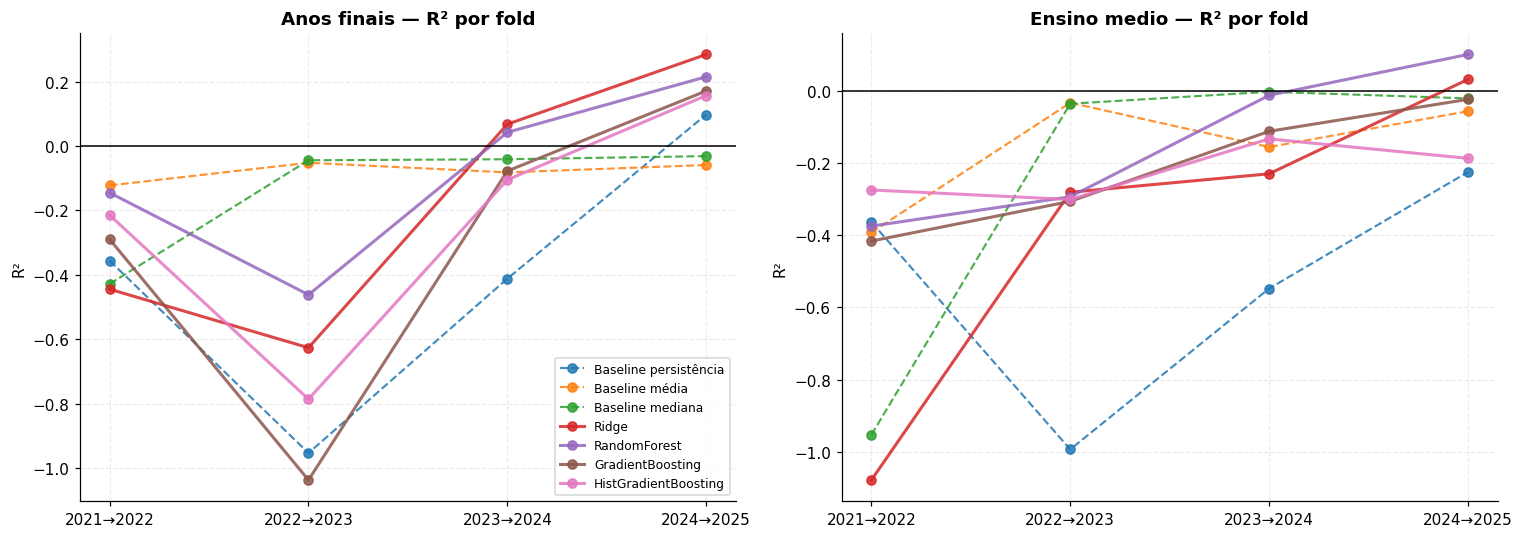

In [9]:
# ------------------------------------------------------------
# 6.3 Gráfico: R² ao longo dos folds
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=110)
for ax, (nome, res) in zip(axes, RESULTADOS.items()):
    for modelo in ORDEM:
        sub = res[res["modelo"] == modelo].sort_values("ano_teste")
        if sub.empty:
            continue
        estilo = "--" if modelo.startswith("Baseline") else "-"
        largura = 1.4 if modelo.startswith("Baseline") else 2.0
        ax.plot(sub["fold"], sub["R2"], estilo, marker="o",
                linewidth=largura, label=modelo, alpha=0.85)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{nome} — R² por fold", fontweight="bold")
    ax.set_ylabel("R²")
    ax.grid(alpha=0.25, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 7. TESTE FINAL — features de 2024 → alvo de 2025
# ------------------------------------------------------------
# Este é o par mais recente com desfecho conhecido. É o número que vai para
# o artigo, sempre ao lado dos baselines e com intervalo de confiança.
# ============================================================
TESTE_FINAL = {}
for nome, dados in DADOS.items():
    X, y, meta = dados["X"], dados["y"], dados["meta"]
    num_cols, cat_cols = dados["num"], dados["cat"]
    col_persist = dados["cfg"]["persistencia"]

    tr = meta["ANO"] < ANO_TESTE_FINAL
    te = meta["ANO"] == ANO_TESTE_FINAL
    X_tr, X_te, y_tr, y_te = X[tr], X[te], y[tr], y[te]
    p_tr = meta.loc[tr, col_persist].to_numpy(dtype=float)
    p_te = meta.loc[te, col_persist].to_numpy(dtype=float)

    preds = dict(previsoes_baseline(y_tr, p_tr, p_te))
    pipes = {}
    for m_nome, modelo in modelos_regressao().items():
        pipe = montar_pipeline(modelo, num_cols, cat_cols)
        pipe.fit(X_tr, y_tr)
        preds[m_nome] = pipe.predict(X_te)
        pipes[m_nome] = pipe

    linhas = []
    for m_nome, yp in preds.items():
        met = metricas_regressao(y_te, yp)
        lo_mae, hi_mae = ic_bootstrap(y_te, yp, "MAE")
        lo_r2, hi_r2 = ic_bootstrap(y_te, yp, "R2")
        linhas.append({
            "modelo": m_nome,
            "MAE": met["MAE"], "MAE_IC95": f"[{lo_mae:.2f}; {hi_mae:.2f}]",
            "RMSE": met["RMSE"],
            "R2": met["R2"], "R2_IC95": f"[{lo_r2:.3f}; {hi_r2:.3f}]",
            "Spearman": met["Spearman"],
        })

    tabela = pd.DataFrame(linhas).set_index("modelo").reindex(ORDEM)
    TESTE_FINAL[nome] = dict(tabela=tabela, preds=preds, pipes=pipes,
                             y_te=y_te, y_tr=y_tr, X_tr=X_tr, X_te=X_te,
                             meta_te=meta[te], p_te=p_te)

    print(f"\n{'=' * 90}")
    print(f"{nome} — treino ANO ≤ {ANO_TESTE_FINAL - 1} | teste ANO = {ANO_TESTE_FINAL} "
          f"(alvo {ANO_TESTE_FINAL + 1})")
    print(f"n treino = {tr.sum():,} | n teste = {te.sum():,}")
    print(f"{'=' * 90}")
    print(tabela.round(3).to_string())
    print("\nMAE e RMSE em pontos percentuais (p.p.).")


Anos finais — treino ANO ≤ 2023 | teste ANO = 2024 (alvo 2025)
n treino = 939 | n teste = 243
                         MAE      MAE_IC95   RMSE     R2           R2_IC95  Spearman
modelo                                                                              
Baseline persistência  2.413  [2.04; 2.80]  3.984  0.098   [-0.260; 0.377]     0.411
Baseline média         3.335  [3.02; 3.66]  4.316 -0.059  [-0.192; -0.010]       NaN
Baseline mediana       2.598  [2.20; 3.02]  4.259 -0.031  [-0.071; -0.004]       NaN
Ridge                  2.518  [2.23; 2.81]  3.548  0.284    [0.096; 0.414]     0.500
RandomForest           2.751  [2.46; 3.05]  3.716  0.215    [0.004; 0.350]     0.399
GradientBoosting       2.833  [2.55; 3.16]  3.818  0.171   [-0.063; 0.322]     0.383
HistGradientBoosting   2.788  [2.48; 3.12]  3.851  0.157   [-0.073; 0.304]     0.347

MAE e RMSE em pontos percentuais (p.p.).

Ensino medio — treino ANO ≤ 2023 | teste ANO = 2024 (alvo 2025)
n treino = 652 | n teste = 171
  

In [11]:
# ============================================================
# 8. IMPORTÂNCIA DE VARIÁVEIS — PERMUTATION IMPORTANCE
# ------------------------------------------------------------
# Correção 10. A importância por impureza (`feature_importances_`) se divide
# entre variáveis colineares: TDI_FUN_TOTAL e TDI_FUN_AF medem quase a mesma
# coisa, e o valor de cada uma depende de qual a árvore sorteou primeiro.
# A permutation importance é medida no conjunto de teste e não tem esse viés.
#
# Continua valendo a ressalva do orientador: isto é contribuição PREDITIVA,
# não causalidade.
# ============================================================
def importancia_permutacao(pipe, X_te, y_te, num_cols, cat_cols, topn=15):
    r = permutation_importance(
        pipe, X_te, y_te, n_repeats=30,
        random_state=RANDOM_STATE, scoring="r2", n_jobs=-1,
    )
    imp = (pd.DataFrame({
        "variavel": list(num_cols) + list(cat_cols),
        "queda_media_R2": r.importances_mean,
        "desvio": r.importances_std,
    })
        .sort_values("queda_media_R2", ascending=False)
        .head(topn)
        .reset_index(drop=True))
    return imp


IMPORTANCIAS = {}
for nome, tf in TESTE_FINAL.items():
    # modelo com melhor R² médio no walk-forward, ignorando os baselines
    res = RESULTADOS[nome]
    candidatos = res[~res["modelo"].str.startswith("Baseline")]
    melhor = candidatos.groupby("modelo")["R2"].mean().idxmax()

    imp = importancia_permutacao(
        tf["pipes"][melhor], tf["X_te"], tf["y_te"],
        DADOS[nome]["num"], DADOS[nome]["cat"],
    )
    IMPORTANCIAS[nome] = dict(modelo=melhor, tabela=imp)
    print(f"\n{'=' * 70}")
    print(f"{nome} — permutation importance ({melhor}, teste {ANO_TESTE_FINAL})")
    print(f"{'=' * 70}")
    print(imp.round(4).to_string(index=False))


Anos finais — permutation importance (RandomForest, teste 2024)
              variavel  queda_media_R2  desvio
         TDI_FUN_TOTAL          0.1597  0.0284
            TDI_FUN_AF          0.0934  0.0163
      APROVACAO_FUN_AF          0.0864  0.0201
     REPROVACAO_FUN_AF          0.0665  0.0242
       ABANDONO_FUN_AF          0.0497  0.0123
         APROVACAO_FUN          0.0421  0.0140
          ABANDONO_FUN          0.0219  0.0068
        REPROVACAO_FUN          0.0191  0.0053
            TDI_FUN_AI          0.0142  0.0054
            IED_FUN_N1          0.0134  0.0060
ABANDONO_FUN_AF_DELTA1          0.0126  0.0042
           LOCALIZACAO          0.0105  0.0031
          CO_MUNICIPIO          0.0071  0.0056
            IED_FUN_N4          0.0070  0.0054
            IED_FUN_N3          0.0047  0.0046

Ensino medio — permutation importance (RandomForest, teste 2024)
            variavel  queda_media_R2  desvio
       TDI_MED_TOTAL          0.1635  0.0403
        ABANDONO_MED       

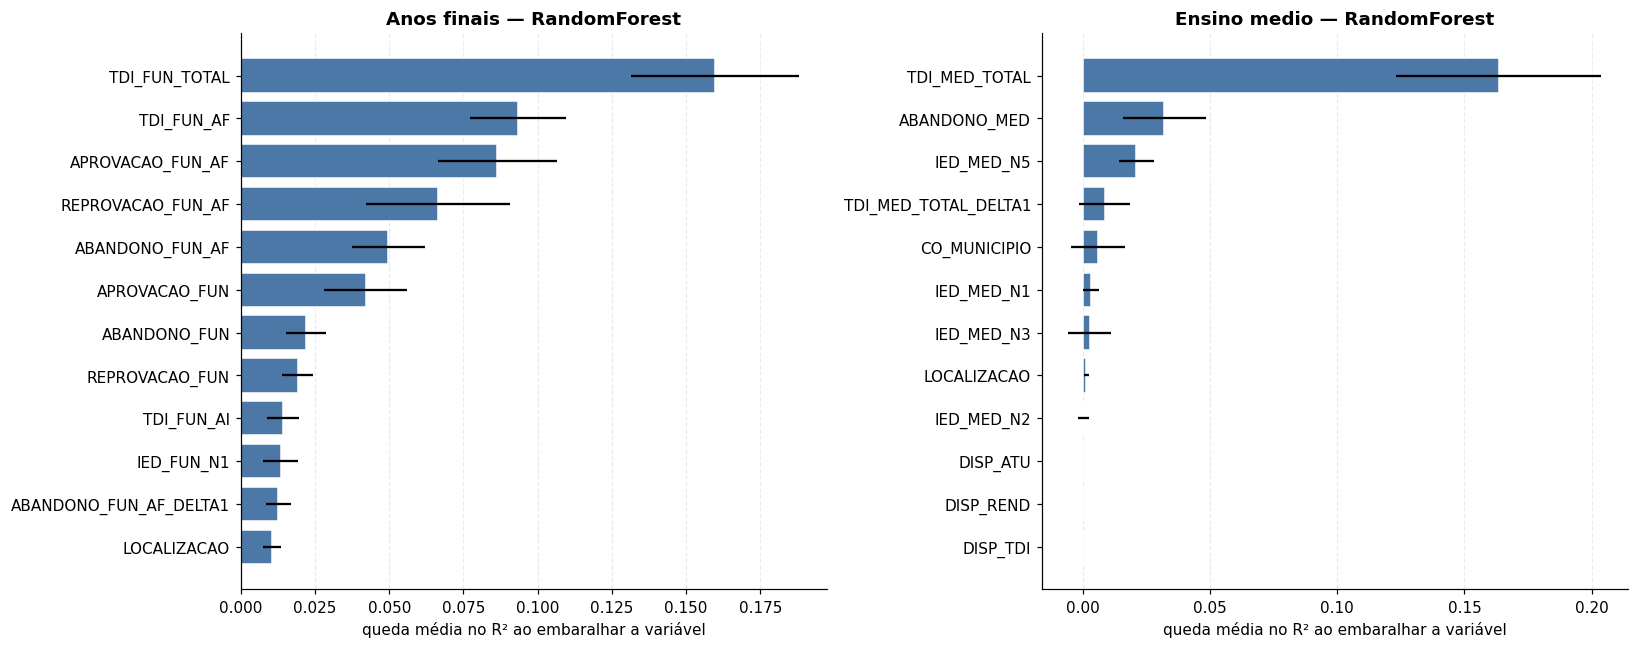

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=110)
for ax, (nome, d) in zip(axes, IMPORTANCIAS.items()):
    t = d["tabela"].head(12).iloc[::-1]
    ax.barh(t["variavel"], t["queda_media_R2"],
            xerr=t["desvio"], color="#4C78A8", edgecolor="white")
    ax.set_title(f"{nome} — {d['modelo']}", fontweight="bold")
    ax.set_xlabel("queda média no R² ao embaralhar a variável")
    ax.grid(axis="x", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 9. SEGUNDA TAREFA — CLASSIFICAÇÃO DE RISCO
# ------------------------------------------------------------
# Correção 8. Precisão, recall, F1, ROC-AUC e PR-AUC só existem num problema
# de classificação, como o orientador observou.
#
# O limiar (Q10, em aberto) é o percentil 80 do alvo NO TREINO. Calculá-lo no
# conjunto completo seria leakage. A acurácia é reportada apenas por
# completude: com ~20% de positivos, prever "baixo risco" para todas já daria
# ~80%. A métrica que importa aqui é o recall, e o PR-AUC é comparado à taxa
# de positivos (que é o valor de um classificador aleatório).
# ============================================================
def modelos_classificacao():
    return {
        "LogisticRegression": LogisticRegression(
            max_iter=2000, random_state=RANDOM_STATE,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, max_depth=10, min_samples_leaf=3,
            random_state=RANDOM_STATE, n_jobs=-1,
        ),
        "HistGradientBoosting": HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.05, max_depth=6,
            random_state=RANDOM_STATE,
        ),
    }


CLASSIFICACAO = {}
for nome, dados in DADOS.items():
    X, y, meta = dados["X"], dados["y"], dados["meta"]
    num_cols, cat_cols = dados["num"], dados["cat"]
    col_persist = dados["cfg"]["persistencia"]

    tr = meta["ANO"] < ANO_TESTE_FINAL
    te = meta["ANO"] == ANO_TESTE_FINAL
    X_tr, X_te, y_tr, y_te = X[tr], X[te], y[tr], y[te]

    limiar = float(np.percentile(y_tr, PERCENTIL_RISCO))   # só o treino
    yb_tr = (y_tr > limiar).astype(int)
    yb_te = (y_te > limiar).astype(int)
    taxa_base = yb_te.mean()

    p_te = meta.loc[te, col_persist].to_numpy(dtype=float)
    p_te = np.where(np.isfinite(p_te), p_te, float(np.nanmedian(y_tr)))

    linhas = [{
        "modelo": "Baseline persistência",
        "Acuracia": ((p_te > limiar).astype(int) == yb_te).mean(),
        "Precisao": precision_score(yb_te, (p_te > limiar).astype(int), zero_division=0),
        "Recall": recall_score(yb_te, (p_te > limiar).astype(int), zero_division=0),
        "F1": f1_score(yb_te, (p_te > limiar).astype(int), zero_division=0),
        "ROC_AUC": roc_auc_score(yb_te, p_te),
        "PR_AUC": average_precision_score(yb_te, p_te),
    }]

    scores = {"Baseline persistência": p_te}
    for m_nome, modelo in modelos_classificacao().items():
        pipe = montar_pipeline(modelo, num_cols, cat_cols)
        pipe.fit(X_tr, yb_tr)
        prob = pipe.predict_proba(X_te)[:, 1]
        pred = (prob >= 0.5).astype(int)
        scores[m_nome] = prob
        linhas.append({
            "modelo": m_nome,
            "Acuracia": (pred == yb_te).mean(),
            "Precisao": precision_score(yb_te, pred, zero_division=0),
            "Recall": recall_score(yb_te, pred, zero_division=0),
            "F1": f1_score(yb_te, pred, zero_division=0),
            "ROC_AUC": roc_auc_score(yb_te, prob),
            "PR_AUC": average_precision_score(yb_te, prob),
        })

    # A previsão contínua da regressão também é um escore de risco: basta
    # ordenar as escolas por ela. Entra aqui para que a seção 10 compare as
    # duas rotas (classificar x regredir e ranquear) na mesma métrica.
    melhor_reg = IMPORTANCIAS[nome]["modelo"]
    scores[f"Regressão ({melhor_reg})"] = TESTE_FINAL[nome]["preds"][melhor_reg]
    pred_reg = (TESTE_FINAL[nome]["preds"][melhor_reg] > limiar).astype(int)
    linhas.append({
        "modelo": f"Regressão ({melhor_reg})",
        "Acuracia": (pred_reg == yb_te).mean(),
        "Precisao": precision_score(yb_te, pred_reg, zero_division=0),
        "Recall": recall_score(yb_te, pred_reg, zero_division=0),
        "F1": f1_score(yb_te, pred_reg, zero_division=0),
        "ROC_AUC": roc_auc_score(yb_te, scores[f"Regressão ({melhor_reg})"]),
        "PR_AUC": average_precision_score(yb_te, scores[f"Regressão ({melhor_reg})"]),
    })

    tabela = pd.DataFrame(linhas).set_index("modelo")
    CLASSIFICACAO[nome] = dict(tabela=tabela, limiar=limiar, yb_te=yb_te,
                               scores=scores, taxa_base=taxa_base)

    print(f"\n{'=' * 88}")
    print(f"{nome} — classificação de alto risco (teste {ANO_TESTE_FINAL} → "
          f"{ANO_TESTE_FINAL + 1})")
    print(f"limiar = percentil {PERCENTIL_RISCO} do treino = {limiar:.2f} p.p. "
          f"| positivos no teste = {yb_te.sum()}/{len(yb_te)} ({taxa_base:.1%})")
    print(f"{'=' * 88}")
    print(tabela.round(3).to_string())
    print(f"\nReferência: um classificador aleatório tem ROC-AUC 0,500 e "
          f"PR-AUC ≈ {taxa_base:.3f} (a taxa de positivos).")
    print(f"Prever 'baixo risco' para todas daria acurácia {1 - taxa_base:.1%} "
          f"e recall 0,000.")
    print("""
Atenção ao corte de 0,5 nas colunas Precisao / Recall / F1. Com ~12% de
positivos, quase nenhuma escola chega a 0,5 de probabilidade, e o recall
despenca — não porque o modelo não ordene bem, mas porque o corte está no
lugar errado. ROC-AUC e PR-AUC não dependem do corte, e a seção 10 troca o
corte por um orçamento de K escolas, que é como a Secretaria realmente age.""")


Anos finais — classificação de alto risco (teste 2024 → 2025)
limiar = percentil 80 do treino = 6.14 p.p. | positivos no teste = 30/243 (12.3%)
                          Acuracia  Precisao  Recall     F1  ROC_AUC  PR_AUC
modelo                                                                      
Baseline persistência        0.852     0.421   0.533  0.471    0.749   0.445
LogisticRegression           0.877     0.500   0.133  0.211    0.806   0.419
RandomForest                 0.889     1.000   0.100  0.182    0.844   0.494
HistGradientBoosting         0.877     0.500   0.167  0.250    0.771   0.313
Regressão (RandomForest)     0.872     0.474   0.300  0.367    0.812   0.381

Referência: um classificador aleatório tem ROC-AUC 0,500 e PR-AUC ≈ 0.123 (a taxa de positivos).
Prever 'baixo risco' para todas daria acurácia 87.7% e recall 0,000.

Atenção ao corte de 0,5 nas colunas Precisao / Recall / F1. Com ~12% de
positivos, quase nenhuma escola chega a 0,5 de probabilidade, e o recall
des

In [14]:
# ============================================================
# 10. MÉTRICA OPERACIONAL — Recall@K e Precision@K
# ------------------------------------------------------------
# Correção 9. É a pergunta que o orientador considera a mais importante:
# "se o Estado puder atuar em apenas K escolas, quantas das que realmente
# tiveram abandono elevado estariam nessa lista?"
#
# Cada K é comparado com (a) a persistência e (b) o acaso. Sortear K escolas
# entre N acerta, em média, K/N dos positivos — sem esse piso o número não
# significa nada.
# ============================================================
def recall_at_k(scores, y_binario, ks=(10, 20, 30, 50)):
    y_binario = np.asarray(y_binario, dtype=int)
    n, n_pos = len(y_binario), int(y_binario.sum())
    ordem = np.argsort(-np.asarray(scores, dtype=float), kind="stable")
    linhas = []
    for k in ks:
        if k > n:
            continue
        topo = y_binario[ordem[:k]]
        linhas.append({
            "K": k,
            "K/N": k / n,
            "acertos": int(topo.sum()),
            "Precision@K": topo.sum() / k,
            "Recall@K": topo.sum() / n_pos if n_pos else np.nan,
            "Recall@K_acaso": k / n,
            "lift": (topo.sum() / k) / (n_pos / n) if n_pos else np.nan,
        })
    return pd.DataFrame(linhas)


for nome, cl in CLASSIFICACAO.items():
    yb = cl["yb_te"]
    print(f"\n{'=' * 92}")
    print(f"{nome} — Recall@K / Precision@K (teste {ANO_TESTE_FINAL} → "
          f"{ANO_TESTE_FINAL + 1})")
    print(f"{int(yb.sum())} escolas de alto risco entre {len(yb)} avaliadas")
    print(f"{'=' * 92}")
    for m_nome, sc in cl["scores"].items():
        tab = recall_at_k(sc, yb)
        print(f"\n--- {m_nome} ---")
        print(tab.round(3).to_string(index=False))


Anos finais — Recall@K / Precision@K (teste 2024 → 2025)
30 escolas de alto risco entre 243 avaliadas

--- Baseline persistência ---
 K   K/N  acertos  Precision@K  Recall@K  Recall@K_acaso  lift
10 0.041        6         0.60     0.200           0.041 4.860
20 0.082       11         0.55     0.367           0.082 4.455
30 0.123       15         0.50     0.500           0.123 4.050
50 0.206       17         0.34     0.567           0.206 2.754

--- LogisticRegression ---
 K   K/N  acertos  Precision@K  Recall@K  Recall@K_acaso  lift
10 0.041        4        0.400     0.133           0.041 3.240
20 0.082       10        0.500     0.333           0.082 4.050
30 0.123       13        0.433     0.433           0.123 3.510
50 0.206       18        0.360     0.600           0.206 2.916

--- RandomForest ---
 K   K/N  acertos  Precision@K  Recall@K  Recall@K_acaso  lift
10 0.041        5        0.500     0.167           0.041 4.050
20 0.082       12        0.600     0.400           0.082 4.8

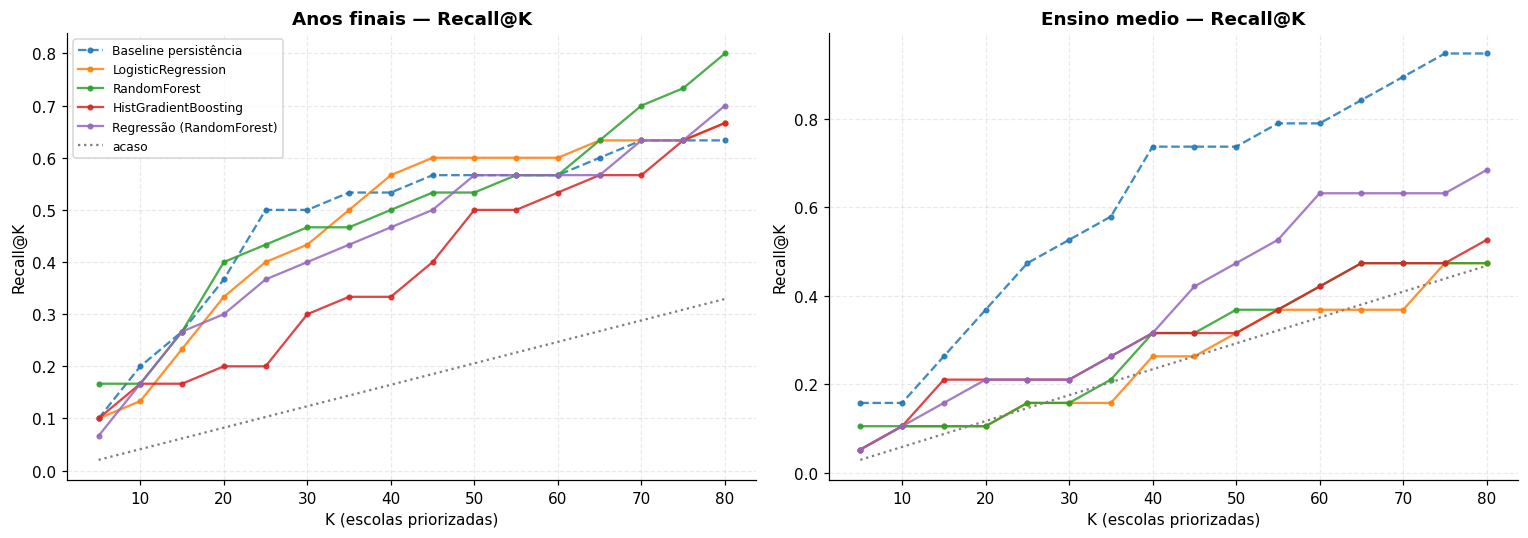

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=110)
for ax, (nome, cl) in zip(axes, CLASSIFICACAO.items()):
    yb = cl["yb_te"]
    ks = list(range(5, min(80, len(yb)) + 1, 5))
    for m_nome, sc in cl["scores"].items():
        tab = recall_at_k(sc, yb, ks=ks)
        estilo = "--" if m_nome.startswith("Baseline") else "-"
        ax.plot(tab["K"], tab["Recall@K"], estilo, marker="o",
                markersize=3, label=m_nome, alpha=0.85)
    tab = recall_at_k(cl["scores"]["Baseline persistência"], yb, ks=ks)
    ax.plot(tab["K"], tab["Recall@K_acaso"], ":", color="gray", label="acaso")
    ax.set_title(f"{nome} — Recall@K", fontweight="bold")
    ax.set_xlabel("K (escolas priorizadas)")
    ax.set_ylabel("Recall@K")
    ax.grid(alpha=0.25, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 11. ANÁLISE DE ERROS
# ------------------------------------------------------------
# O orientador pediu isto explicitamente: "não adianta ter bom erro médio se
# justamente uma escola que terá 20% de abandono recebe previsão de 4%".
# ============================================================
for nome, tf in TESTE_FINAL.items():
    melhor = IMPORTANCIAS[nome]["modelo"]
    yp = tf["preds"][melhor]
    y_te = tf["y_te"].to_numpy(dtype=float)
    m = tf["meta_te"].copy()
    m["real"] = y_te
    m["previsto"] = yp
    m["erro"] = m["previsto"] - m["real"]

    print(f"\n{'=' * 96}")
    print(f"{nome} — 10 maiores subestimações ({melhor})")
    print("(escolas de alto abandono que o modelo não antecipou — o erro caro)")
    print(f"{'=' * 96}")
    piores = m.nsmallest(10, "erro")[["CO_ENTIDADE", "ANO", "real", "previsto", "erro"]]
    print(piores.round(2).to_string(index=False))

    # Quanto do erro quadrático total está concentrado em poucas escolas?
    sq = np.sort((m["erro"] ** 2).to_numpy())[::-1]
    for frac in (0.05, 0.10):
        k = max(1, int(len(sq) * frac))
        print(f"\n  As {frac:.0%} piores escolas ({k}) concentram "
              f"{sq[:k].sum() / sq.sum():.1%} do erro quadrático total.")


Anos finais — 10 maiores subestimações (RandomForest)
(escolas de alto abandono que o modelo não antecipou — o erro caro)
CO_ENTIDADE  ANO  real  previsto   erro
   14008963 2024  22.2      3.09 -19.11
   14003368 2024  15.0      2.21 -12.79
   14003350 2024  25.0     12.43 -12.57
   14369656 2024  17.1      5.36 -11.74
   14000385 2024  19.4      8.75 -10.65
   14003171 2024  15.3      4.96 -10.34
   14002825 2024  14.9      5.16  -9.74
   14000032 2024  11.7      2.54  -9.16
   14005085 2024  16.1      7.09  -9.01
   14322668 2024  15.2      6.66  -8.54

  As 5% piores escolas (12) concentram 45.1% do erro quadrático total.

  As 10% piores escolas (24) concentram 58.8% do erro quadrático total.

Ensino medio — 10 maiores subestimações (RandomForest)
(escolas de alto abandono que o modelo não antecipou — o erro caro)
CO_ENTIDADE  ANO  real  previsto   erro
   14003171 2024  45.0      9.27 -35.73
   14007053 2024  26.2      5.03 -21.17
   14001144 2024  27.3      8.11 -19.19
   14000

In [17]:
# ------------------------------------------------------------
# 11.1 Desempenho por grupo
# ------------------------------------------------------------
# Enquanto a base não tiver as flags de escola indígena / terra indígena /
# assentamento (Fase 3), dá para quebrar por localização e dependência.
# ------------------------------------------------------------
for nome, tf in TESTE_FINAL.items():
    melhor = IMPORTANCIAS[nome]["modelo"]
    m = tf["meta_te"].copy()
    m["real"] = tf["y_te"].to_numpy(dtype=float)
    m["previsto"] = tf["preds"][melhor]
    m["erro_abs"] = (m["previsto"] - m["real"]).abs()
    m = m.join(df[["LOCALIZACAO", "DEPENDENCIA"]], how="left")

    print(f"\n=== {nome} — MAE por grupo ({melhor}) ===")
    for col in ("LOCALIZACAO", "DEPENDENCIA"):
        g = (m.groupby(col, observed=True)
             .agg(n=("erro_abs", "size"),
                  MAE=("erro_abs", "mean"),
                  abandono_medio=("real", "mean"))
             .round(2))
        print(f"\n{g.to_string()}")


=== Anos finais — MAE por grupo (RandomForest) ===

               n   MAE  abandono_medio
LOCALIZACAO                           
Rural        165  3.32            3.26
Urbana        78  1.55            1.02

               n   MAE  abandono_medio
DEPENDENCIA                           
Estadual     214  2.74            2.72
Federal        1  1.58            0.00
Municipal     28  2.85            1.24

=== Ensino medio — MAE por grupo (RandomForest) ===

               n   MAE  abandono_medio
LOCALIZACAO                           
Rural        115  4.96            7.68
Urbana        56  3.09            3.32

               n   MAE  abandono_medio
DEPENDENCIA                           
Estadual     167  4.37            6.40
Federal        4  3.56            0.25


In [18]:
# ============================================================
# 12. SENSIBILIDADE — A PANDEMIA ESTÁ NO LUGAR CERTO?
# ------------------------------------------------------------
# Os relatórios do projeto descrevem um "pico em 2022" e a Q4 propõe tirar 2022
# do treino. Os dados da base dizem outra coisa: o abandono em 2022 é o RETORNO
# ao patamar de 2019. A anomalia é o VALE de 2020, quando quase não houve
# reprovação nem registro de abandono.
#
# Tirar 2022 removeria o ano normal e manteria o ano anômalo. Esta seção
# mostra a série para a decisão ser tomada com o número na frente.
# ============================================================
serie = (pd.read_parquet(BASE_LONG)
         .query("REDE_PUBLICA == 1")
         .groupby("ANO")[["ABANDONO_FUN_AF", "ABANDONO_MED"]]
         .agg(["mean", "median"])
         .round(2))
print("Abandono CONTEMPORÂNEO por ano (escolas públicas, p.p.)")
print(serie.to_string())
print("""
Leitura: 2019 é o patamar pré-pandemia. 2020 despenca (escolas fechadas,
sem registro normal de frequência). 2021 e 2022 sobem de volta. Chamar 2022
de "pico" e retirá-lo do treino tiraria justamente o ano típico.

Sugestão para a Q4: tratar 2020 (e possivelmente 2021) como anômalos,
e não 2022. A célula abaixo mede o efeito dessa escolha.
""")

Abandono CONTEMPORÂNEO por ano (escolas públicas, p.p.)
     ABANDONO_FUN_AF        ABANDONO_MED       
                mean median         mean median
ANO                                            
2019            5.42    3.7        10.71   7.15
2020            1.04    0.0         1.67    0.0
2021            3.13    1.3         5.83    2.3
2022            5.22    3.5        12.05  10.55
2023            3.16    1.5         7.58    6.0
2024            2.76    1.4         5.74   3.65
2025            2.53    0.8          6.2    4.5

Leitura: 2019 é o patamar pré-pandemia. 2020 despenca (escolas fechadas,
sem registro normal de frequência). 2021 e 2022 sobem de volta. Chamar 2022
de "pico" e retirá-lo do treino tiraria justamente o ano típico.

Sugestão para a Q4: tratar 2020 (e possivelmente 2021) como anômalos,
e não 2022. A célula abaixo mede o efeito dessa escolha.



In [19]:
# ------------------------------------------------------------
# 12.1 Walk-forward sem os anos de pandemia no treino
# ------------------------------------------------------------
ANOS_PANDEMIA = [2020, 2021]
SENSIBILIDADE = {}

for nome, dados in DADOS.items():
    X, y, meta = dados["X"], dados["y"], dados["meta"]
    num_cols, cat_cols = dados["num"], dados["cat"]
    col_persist = dados["cfg"]["persistencia"]

    tr = (meta["ANO"] < ANO_TESTE_FINAL) & (~meta["ANO"].isin(ANOS_PANDEMIA))
    te = meta["ANO"] == ANO_TESTE_FINAL
    if tr.sum() < 50:
        print(f"{nome}: treino pequeno demais sem os anos de pandemia.")
        continue

    p_tr = meta.loc[tr, col_persist].to_numpy(dtype=float)
    p_te = meta.loc[te, col_persist].to_numpy(dtype=float)
    preds = dict(previsoes_baseline(y[tr], p_tr, p_te))
    for m_nome, modelo in modelos_regressao().items():
        pipe = montar_pipeline(modelo, num_cols, cat_cols)
        pipe.fit(X[tr], y[tr])
        preds[m_nome] = pipe.predict(X[te])

    comp = pd.DataFrame({
        m_nome: metricas_regressao(y[te], yp)
        for m_nome, yp in preds.items()
    }).T.reindex(ORDEM)
    comp["R2_com_pandemia"] = TESTE_FINAL[nome]["tabela"]["R2"]
    comp["delta_R2"] = comp["R2"] - comp["R2_com_pandemia"]
    SENSIBILIDADE[nome] = comp

    print(f"\n=== {nome} — treino sem {ANOS_PANDEMIA} (n={tr.sum()}) ===")
    print(comp[["MAE", "RMSE", "R2", "R2_com_pandemia", "delta_R2"]].round(3).to_string())


=== Anos finais — treino sem [2020, 2021] (n=471) ===
                         MAE   RMSE     R2  R2_com_pandemia  delta_R2
Baseline persistência  2.430  3.992  0.094            0.098    -0.003
Baseline média         3.018  4.214 -0.009           -0.059     0.049
Baseline mediana       2.521  4.347 -0.074           -0.031    -0.043
Ridge                  2.260  3.580  0.271            0.284    -0.013
RandomForest           2.334  3.576  0.273            0.215     0.058
GradientBoosting       2.520  3.826  0.167            0.171    -0.003
HistGradientBoosting   2.524  3.871  0.148            0.157    -0.009

=== Ensino medio — treino sem [2020, 2021] (n=334) ===
                         MAE   RMSE     R2  R2_com_pandemia  delta_R2
Baseline persistência  4.888  7.245 -0.217           -0.225     0.008
Baseline média         4.959  6.581 -0.004           -0.057     0.052
Baseline mediana       4.735  6.705 -0.042           -0.021    -0.021
Ridge                  4.060  5.951  0.179       

In [20]:
# ============================================================
# 13. RESUMO
# ============================================================
print("=" * 96)
print("RESUMO — v1_corrigido")
print("=" * 96)

for nome in ETAPAS:
    tab = TESTE_FINAL[nome]["tabela"]
    res = RESULTADOS[nome]
    melhor = IMPORTANCIAS[nome]["modelo"]
    cl = CLASSIFICACAO[nome]

    persist_mae = tab.loc["Baseline persistência", "MAE"]
    modelo_mae = tab.loc[melhor, "MAE"]
    ganho = (persist_mae - modelo_mae) / persist_mae

    print(f"\n### {nome}")
    print(f"  Melhor modelo no walk-forward : {melhor}")
    print(f"  R² médio entre folds          : "
          f"{res[res.modelo == melhor]['R2'].mean():.3f} "
          f"(± {res[res.modelo == melhor]['R2'].std():.3f})")
    print(f"  Folds com R² negativo         : "
          f"{(res[res.modelo == melhor]['R2'] < 0).sum()} de "
          f"{len(res[res.modelo == melhor])}")
    print(f"  Teste {ANO_TESTE_FINAL}→{ANO_TESTE_FINAL + 1}  MAE          : "
          f"{modelo_mae:.2f} p.p.  {tab.loc[melhor, 'MAE_IC95']}")
    print(f"  Baseline persistência    MAE  : {persist_mae:.2f} p.p.")
    print(f"  Ganho sobre a persistência    : {ganho:+.1%}")
    print(f"  R²                            : {tab.loc[melhor, 'R2']:.3f} "
          f"{tab.loc[melhor, 'R2_IC95']}")
    print(f"  Top-1 permutation importance  : "
          f"{IMPORTANCIAS[nome]['tabela'].iloc[0]['variavel']}")

    melhor_cl = cl["tabela"]["PR_AUC"].idxmax()
    print(f"  Classificação — melhor PR-AUC : {melhor_cl} "
          f"({cl['tabela'].loc[melhor_cl, 'PR_AUC']:.3f}, "
          f"acaso = {cl['taxa_base']:.3f})")

    r30_mod = recall_at_k(cl["scores"][melhor_cl], cl["yb_te"], ks=(30,))
    r30_bas = recall_at_k(cl["scores"]["Baseline persistência"], cl["yb_te"], ks=(30,))
    if not r30_mod.empty:
        print(f"  Recall@30 — {melhor_cl[:22]:<22}: "
              f"{r30_mod.iloc[0]['Recall@K']:.1%}")
        print(f"  Recall@30 — persistência      : "
              f"{r30_bas.iloc[0]['Recall@K']:.1%}")
        print(f"  Recall@30 — acaso             : "
              f"{r30_bas.iloc[0]['Recall@K_acaso']:.1%}")

    if nome in SENSIBILIDADE:
        s = SENSIBILIDADE[nome]
        d = s.loc[melhor, "delta_R2"]
        print(f"  Tirar 2020–2021 do treino     : R² {s.loc[melhor, 'R2_com_pandemia']:.3f} "
              f"→ {s.loc[melhor, 'R2']:.3f} ({d:+.3f})")

print("""
==============================================================================
PENDENTE (não dá para resolver só com a base longitudinal)
==============================================================================
  - Fase 3: escola indígena, terra indígena, assentamento, multisseriada,
    HAD, IED 2019-2020. Exige voltar aos microdados do Censo.
  - Matrícula por escola. A base não tem nenhuma coluna de tamanho, e sem ela
    não dá para ponderar as taxas nem separar escola pequena de grande.
  - SHAP, para confirmar a permutation importance.
  - Q4 (pandemia): ver seção 12.
  - Q10 (limiar de alto risco): hoje percentil 80 do treino. Decidir.
==============================================================================
""")

RESUMO — v1_corrigido

### Anos finais
  Melhor modelo no walk-forward : RandomForest
  R² médio entre folds          : -0.087 (± 0.290)
  Folds com R² negativo         : 2 de 4
  Teste 2024→2025  MAE          : 2.75 p.p.  [2.46; 3.05]
  Baseline persistência    MAE  : 2.41 p.p.
  Ganho sobre a persistência    : -14.0%
  R²                            : 0.215 [0.004; 0.350]
  Top-1 permutation importance  : TDI_FUN_TOTAL
  Classificação — melhor PR-AUC : RandomForest (0.494, acaso = 0.123)
  Recall@30 — RandomForest          : 46.7%
  Recall@30 — persistência      : 50.0%
  Recall@30 — acaso             : 12.3%
  Tirar 2020–2021 do treino     : R² 0.215 → 0.273 (+0.058)

### Ensino medio
  Melhor modelo no walk-forward : RandomForest
  R² médio entre folds          : -0.145 (± 0.226)
  Folds com R² negativo         : 3 de 4
  Teste 2024→2025  MAE          : 4.35 p.p.  [3.72; 5.07]
  Baseline persistência    MAE  : 4.92 p.p.
  Ganho sobre a persistência    : +11.5%
  R²                  